In [2]:
import os

import numpy as np
import polars as pl
from aeon.classification.convolution_based import (
    MultiRocketClassifier,
    RocketClassifier,
)
from aeon.classification.feature_based import (
    Catch22Classifier,
)
from aeon.classification.interval_based import QUANTClassifier
from aeon.datasets.tsc_datasets import univariate
from sklearn.metrics import accuracy_score
from tqdm import tqdm

from autotsc import models, utils

2025-12-03 13:53:38.715193: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
write_dir = "experiments/automl_val_vs_test_accuracy"
os.makedirs(write_dir, exist_ok=True)

In [4]:
datasets = list(univariate)
# random.shuffle(datasets)

In [5]:
def get_model(model_name: str, seed: int):
    if model_name == "rocket":
        model = RocketClassifier(
            n_jobs=-1,
            random_state=seed,
            estimator=models.RidgeClassifierCVWithProba(alphas=np.logspace(-3, 3, 10)),
        )
    elif model_name == "multirocket":
        model = MultiRocketClassifier(
            n_jobs=-1,
            random_state=seed,
            estimator=models.RidgeClassifierCVWithProba(alphas=np.logspace(-3, 3, 10)),
        )
    elif model_name == "catch22":
        model = Catch22Classifier(random_state=seed, n_jobs=-1)
    elif model_name == "quant":
        model = QUANTClassifier(random_state=seed)
    elif model_name == "hydra":
        from aeon.classification.convolution_based import HydraClassifier

        model = HydraClassifier(random_state=seed, n_jobs=-1)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return model

In [ ]:
for dataset in tqdm(datasets):
    for model_name in ["rocket", "catch22", "quant", "hydra", "multirocket"]:
        for run in range(2):
            stats = {
                "dataset": dataset,
                "model": model_name,
                "run": run,
            }

            hash_val = pl.DataFrame([stats]).hash_rows(seed=42, seed_1=1, seed_2=2, seed_3=3).item()
            file = f"{write_dir}/{hash_val}.parquet"

            if os.path.exists(file):
                print(f"Skipping: Dataset={dataset}, Run={run}, Model={model_name}")
                continue

            model = get_model(model_name, seed=run)
            X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
            model.fit(X_train, y_train)
            test_preds = model.predict(X_test)
            test_pred_probs = model.predict_proba(X_test)
            test_acc = accuracy_score(y_test, test_preds)

            folds = utils.get_folds(
                X_train, y_train, n_splits=min(20, len(X_train)), random_state=run
            )

            preds = []
            true = []
            pred_probas = []
            for train_idx, val_idx in folds:
                X_tr, y_tr = X_train[train_idx], y_train[train_idx]
                X_val, y_val = X_train[val_idx], y_train[val_idx]

                fold_model = get_model(model_name, seed=run)
                fold_model.fit(X_tr, y_tr)
                val_preds = fold_model.predict(X_val)
                val_pred_probs = fold_model.predict_proba(X_val)

                preds.extend(zip(val_idx, val_preds))
                true.extend(zip(val_idx, y_val))
                pred_probas.extend(zip(val_idx, val_pred_probs))

            preds = sorted(preds, key=lambda x: x[0])
            true = sorted(true, key=lambda x: x[0])
            pred_probas = sorted(pred_probas, key=lambda x: x[0])
            preds = [x[1].item() for x in preds]
            true = [x[1].item() for x in true]
            pred_probas = [x[1].tolist() for x in pred_probas]

            vall_acc = accuracy_score(true, preds)

            stats["test_acc"] = test_acc
            stats["vall_acc"] = vall_acc
            stats["test_true"] = list(y_test)
            stats["val_true"] = list(true)
            stats["test_preds"] = list(test_preds)
            stats["val_preds"] = list(preds)
            stats["test_probabilities"] = list(test_pred_probs)
            stats["val_probabilities"] = list(pred_probas)

            df_stat = pl.DataFrame([stats])
            df_stat.write_parquet(file, mkdir=True)

            print(f"Saved: Dataset={dataset}, Run={run}, Model={model_name}")

  0%|          | 0/128 [00:00<?, ?it/s]

Skipping: Dataset=ACSF1, Run=0, Model=rocket
StratifiedKFold failed, falling back to regular KFold with n_splits=20
Saved: Dataset=ACSF1, Run=1, Model=rocket
Skipping: Dataset=ACSF1, Run=0, Model=catch22
StratifiedKFold failed, falling back to regular KFold with n_splits=20
Saved: Dataset=ACSF1, Run=1, Model=catch22
Skipping: Dataset=ACSF1, Run=0, Model=quant
StratifiedKFold failed, falling back to regular KFold with n_splits=20
Saved: Dataset=ACSF1, Run=1, Model=quant
Skipping: Dataset=ACSF1, Run=0, Model=hydra
StratifiedKFold failed, falling back to regular KFold with n_splits=20
Saved: Dataset=ACSF1, Run=1, Model=hydra
Skipping: Dataset=ACSF1, Run=0, Model=multirocket
StratifiedKFold failed, falling back to regular KFold with n_splits=20


  1%|          | 1/128 [01:37<3:25:59, 97.32s/it]

Saved: Dataset=ACSF1, Run=1, Model=multirocket
Skipping: Dataset=Adiac, Run=0, Model=rocket
StratifiedKFold failed, falling back to regular KFold with n_splits=20
Saved: Dataset=Adiac, Run=1, Model=rocket
Skipping: Dataset=Adiac, Run=0, Model=catch22
StratifiedKFold failed, falling back to regular KFold with n_splits=20
Saved: Dataset=Adiac, Run=1, Model=catch22
Skipping: Dataset=Adiac, Run=0, Model=quant
StratifiedKFold failed, falling back to regular KFold with n_splits=20
Saved: Dataset=Adiac, Run=1, Model=quant
Skipping: Dataset=Adiac, Run=0, Model=hydra
StratifiedKFold failed, falling back to regular KFold with n_splits=20
Saved: Dataset=Adiac, Run=1, Model=hydra
Skipping: Dataset=Adiac, Run=0, Model=multirocket
StratifiedKFold failed, falling back to regular KFold with n_splits=20


  2%|▏         | 2/128 [03:02<3:09:56, 90.44s/it]

...

Saved: Dataset=ECGFiveDays, Run=1, Model=multirocket
Skipping: Dataset=ElectricDevices, Run=0, Model=rocket
Saved: Dataset=ElectricDevices, Run=1, Model=rocket
Skipping: Dataset=ElectricDevices, Run=0, Model=catch22
Saved: Dataset=ElectricDevices, Run=1, Model=catch22
Skipping: Dataset=ElectricDevices, Run=0, Model=quant
Saved: Dataset=ElectricDevices, Run=1, Model=quant
Skipping: Dataset=ElectricDevices, Run=0, Model=hydra
Saved: Dataset=ElectricDevices, Run=1, Model=hydra
Skipping: Dataset=ElectricDevices, Run=0, Model=multirocket


 26%|██▌       | 33/128 [3:32:33<48:03:34, 1821.21s/it]

Saved: Dataset=ElectricDevices, Run=1, Model=multirocket
Skipping: Dataset=EOGHorizontalSignal, Run=0, Model=rocket
Saved: Dataset=EOGHorizontalSignal, Run=1, Model=rocket
Skipping: Dataset=EOGHorizontalSignal, Run=0, Model=catch22
Saved: Dataset=EOGHorizontalSignal, Run=1, Model=catch22
Skipping: Dataset=EOGHorizontalSignal, Run=0, Model=quant
Saved: Dataset=EOGHorizontalSignal, Run=1, Model=quant
Skipping: Dataset=EOGHorizontalSignal, Run=0, Model=hydra
Saved: Dataset=EOGHorizontalSignal, Run=1, Model=hydra
Skipping: Dataset=EOGHorizontalSignal, Run=0, Model=multirocket


 27%|██▋       | 34/128 [3:39:52<36:43:35, 1406.55s/it]

Saved: Dataset=EOGHorizontalSignal, Run=1, Model=multirocket
Skipping: Dataset=EOGVerticalSignal, Run=0, Model=rocket
Saved: Dataset=EOGVerticalSignal, Run=1, Model=rocket
Skipping: Dataset=EOGVerticalSignal, Run=0, Model=catch22
Saved: Dataset=EOGVerticalSignal, Run=1, Model=catch22
Skipping: Dataset=EOGVerticalSignal, Run=0, Model=quant
Saved: Dataset=EOGVerticalSignal, Run=1, Model=quant
Skipping: Dataset=EOGVerticalSignal, Run=0, Model=hydra


In [6]:
df = pl.read_parquet(f"{write_dir}/*.parquet").sort("dataset")
df

dataset,model,run,test_acc,vall_acc,test_true,val_true,test_preds,val_preds,test_probabilities,val_probabilities
str,str,i64,f64,f64,list[str],list[str],list[str],list[str],list[list[f64]],list[list[f64]]
"""ACSF1""","""hydra""",0,0.85,0.75,"[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""4""]","[[0.0, 0.0, … 1.0], [0.0, 0.0, … 1.0], … [0.0, 1.0, … 0.0]]","[[0.0, 0.0, … 1.0], [0.0, 0.0, … 1.0], … [0.0, 0.0, … 0.0]]"
"""ACSF1""","""hydra""",1,0.86,0.72,"[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""4""]","[[0.0, 0.0, … 1.0], [0.0, 0.0, … 1.0], … [0.0, 1.0, … 0.0]]","[[0.0, 0.0, … 1.0], [0.0, 0.0, … 1.0], … [0.0, 0.0, … 0.0]]"
"""ACSF1""","""catch22""",0,0.85,0.65,"[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""4""]","[""9"", ""9"", … ""4""]","[[0.01, 0.0, … 0.86], [0.005, 0.01, … 0.63], … [0.015, 0.345, … 0.0]]","[[0.0, 0.005, … 0.895], [0.0, 0.005, … 0.775], … [0.12, 0.23, … 0.0]]"
"""ACSF1""","""quant""",1,0.92,0.65,"[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""4""]","[[0.0, 0.0, … 0.995], [0.0, 0.0, … 0.935], … [0.02, 0.735, … 0.0]]","[[0.0, 0.0, … 0.975], [0.0, 0.0, … 0.815], … [0.085, 0.39, … 0.0]]"
"""ACSF1""","""multirocket""",1,0.89,0.74,"[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""1""]","[""9"", ""9"", … ""4""]","[[0.080706, 0.079631, … 0.204357], [0.085573, 0.079784, … 0.215414], … [0.100632, 0.197121, … 0.075291]]","[[0.084421, 0.088593, … 0.226584], [0.095712, 0.081873, … 0.208858], … [0.091649, 0.141728, … 0.07548]]"
…,…,…,…,…,…,…,…,…,…,…
"""Yoga""","""rocket""",0,0.910333,0.88,"[""1"", ""2"", … ""2""]","[""1"", ""1"", … ""2""]","[""2"", ""2"", … ""2""]","[""1"", ""1"", … ""2""]","[[0.402495, 0.597505], [0.234227, 0.765773], … [0.323258, 0.676742]]","[[0.52762, 0.47238], [0.712488, 0.287512], … [0.386347, 0.613653]]"
"""Yoga""","""multirocket""",0,0.919,0.916667,"[""1"", ""2"", … ""2""]","[""1"", ""1"", … ""2""]","[""2"", ""2"", … ""2""]","[""1"", ""1"", … ""2""]","[[0.480677, 0.519323], [0.301318, 0.698682], … [0.412535, 0.587465]]","[[0.528426, 0.471574], [0.724332, 0.275668], … [0.421048, 0.578952]]"
"""Yoga""","""hydra""",0,0.926667,0.896667,"[""1"", ""2"", … ""2""]","[""1"", ""1"", … ""2""]","[""1"", ""2"", … ""2""]","[""1"", ""1"", … ""1""]","[[1.0, 0.0], [0.0, 1.0], … [0.0, 1.0]]","[[1.0, 0.0], [1.0, 0.0], … [1.0, 0.0]]"


Text(0, 0.5, 'Test Accuracy')

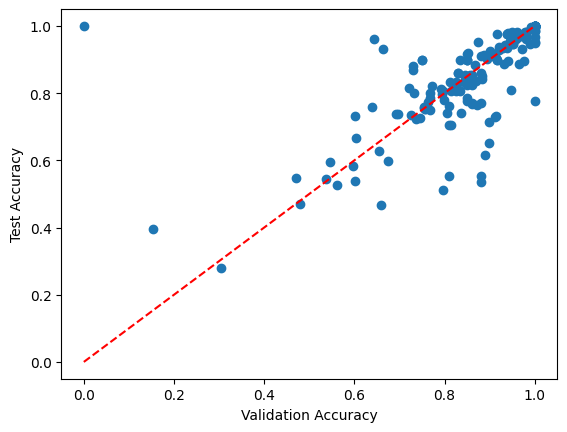

In [7]:
sdf = df.filter(pl.col("model") == "rocket")
import matplotlib.pyplot as plt

plt.plot(sdf["vall_acc"], sdf["test_acc"], "o")
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Validation Accuracy")
plt.ylabel("Test Accuracy")

In [8]:
def get_datasets_stats():
    stats = []
    for dataset in list(univariate):
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": len(X_train),
                "n_test": len(X_test),
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[1],
            }
        )
    return pl.DataFrame(stats)


df_stats = get_datasets_stats()

In [9]:
df_stats

dataset,n_train,n_test,n_classes,series_length
str,i64,i64,i64,i64
"""ACSF1""",100,100,10,1
"""Adiac""",390,391,37,1
"""AllGestureWiimoteX""",300,700,10,1
"""AllGestureWiimoteY""",300,700,10,1
"""AllGestureWiimoteZ""",300,700,10,1
…,…,…,…,…
"""Wine""",57,54,2,1
"""WordSynonyms""",267,638,25,1
"""Worms""",181,77,5,1


In [11]:
models = df.select("model").unique().to_series().to_list()
pvdf = (
    df.pivot(values=["vall_acc"], index="dataset", on="model", aggregate_function="mean")
    .drop_nulls()
    .select(["dataset"] + models)
)
pvdf

dataset,multirocket,hydra,quant,rocket,catch22
str,f64,f64,f64,f64,f64
"""ACSF1""",0.75,0.735,0.665,0.73,0.68
"""Adiac""",0.802564,0.810256,0.766667,0.765385,0.662821
"""AllGestureWiimoteX""",0.758333,0.73,0.675,0.731667,0.671667
"""AllGestureWiimoteY""",0.8,0.748333,0.696667,0.761667,0.638333
"""AllGestureWiimoteZ""",0.713333,0.655,0.641667,0.695,0.595
…,…,…,…,…,…
"""Wine""",1.0,1.0,1.0,1.0,0.877193
"""WordSynonyms""",0.775281,0.7603,0.692884,0.756554,0.52809
"""Worms""",0.756906,0.78453,0.734807,0.745856,0.707182


In [12]:
best_list = pvdf.select(models).to_numpy().argmax(axis=1)
best_list

array([0, 1, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 2, 3, 1, 0, 2, 0, 0, 3, 0, 0,
       1, 0, 3, 0, 0, 0, 0, 0, 1, 0, 3, 4, 0, 2, 0, 0, 0, 0, 1, 2, 1, 2,
       0, 0, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 2, 0, 0, 2, 0, 1,
       0, 3, 0, 0, 0, 2, 0, 0, 2, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       3, 0, 2, 4, 0, 2, 1, 1, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 4, 2, 1, 1,
       0, 3, 0, 1, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [16]:
ptdf = (
    df.pivot(values=["test_acc"], index="dataset", on="model", aggregate_function="mean")
    .drop_nulls()
    .select(["dataset"] + models)
)

In [17]:
from scipy.stats import rankdata

v = ptdf.select(models).to_numpy()
r = pl.DataFrame(rankdata(v, axis=1, method="average"), schema=[f"r-{m}" for m in models])
ptdf = ptdf.hstack(r)
ptdf

dataset,multirocket,hydra,quant,rocket,catch22,r-multirocket,r-hydra,r-quant,r-rocket,r-catch22
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACSF1""",0.89,0.855,0.915,0.875,0.85,4.0,2.0,5.0,3.0,1.0
"""Adiac""",0.826087,0.817136,0.83376,0.780051,0.705882,4.0,3.0,5.0,2.0,1.0
"""AllGestureWiimoteX""",0.757143,0.693571,0.634286,0.73,0.6,5.0,3.0,2.0,4.0,1.0
"""AllGestureWiimoteY""",0.782143,0.730714,0.674286,0.750714,0.662857,5.0,3.0,2.0,4.0,1.0
"""AllGestureWiimoteZ""",0.766429,0.687143,0.662143,0.737143,0.635714,5.0,3.0,2.0,4.0,1.0
…,…,…,…,…,…,…,…,…,…,…
"""Wine""",0.87037,0.907407,0.796296,0.777778,0.407407,4.0,5.0,3.0,2.0,1.0
"""WordSynonyms""",0.778997,0.742947,0.705329,0.752351,0.532915,5.0,3.0,2.0,4.0,1.0
"""Worms""",0.766234,0.753247,0.74026,0.727273,0.727273,5.0,4.0,3.0,1.5,1.5


In [18]:
# select value form oclumns based on best_list
ranks = ptdf.select([f"r-{m}" for m in models]).to_numpy()
best_test_acc = ranks[np.arange(len(best_list)), best_list]
print(best_test_acc)
print(np.mean(best_test_acc))

[4.  3.  5.  5.  5.  5.  3.5 4.  5.  3.5 3.  4.5 3.  5.  5.  3.  4.  4.
 4.5 5.  5.  4.  4.  4.  4.  1.  4.  4.  5.  3.  4.  4.  5.  3.  3.  5.
 3.  3.  4.  5.  5.  5.  4.  4.5 4.  4.  5.  5.  5.  5.  3.  4.  4.  4.
 3.5 4.5 5.  4.  1.  4.  5.  3.  4.  4.  4.  4.  3.  4.  2.  3.5 4.  5.
 2.  4.  5.  4.5 4.5 3.  4.  5.  5.  4.  4.  5.  4.  5.  4.  5.  4.  3.
 5.  1.  5.  2.  3.  5.  4.  5.  5.  5.  4.5 4.5 4.  5.  4.  3.  2.5 2.
 3.5 4.5 4.  5.  4.  3.  3.  3.  4.  3.5 5.  5.  5.  5.  3.  4.  5.  4.
 1.  4. ]
4.0078125


In [19]:
# reorder best list randomly
np.random.shuffle(best_list)
best_test_acc = ranks[np.arange(len(best_list)), best_list]
print(best_test_acc)
print(np.mean(best_test_acc))

[4.  4.  5.  5.  4.  1.  3.5 4.  2.  1.  3.  4.5 2.  3.  3.  3.  5.  4.
 2.  4.  5.  1.  5.  1.  4.  1.  4.  4.  5.  3.  4.  4.  4.  1.5 3.  5.
 2.  3.  4.  3.  3.5 3.  4.  2.  5.  4.  4.  3.5 4.  5.  3.  4.  4.  4.
 3.5 2.  5.  5.  2.5 2.5 3.  3.  4.  5.  2.  3.  1.5 3.  2.  2.  4.  3.
 2.  4.  2.5 4.5 4.5 5.  4.  3.  4.  2.  4.  2.  4.  5.  5.  1.  4.  3.
 5.  3.  5.  4.5 5.  3.  1.  5.  5.  5.  4.5 4.5 4.  1.  2.  3.  1.  2.
 3.5 4.5 4.  4.  4.  5.  3.  3.  4.  3.5 3.  5.  4.  5.  4.5 5.  2.  5.
 2.  4. ]
3.49609375


In [20]:
pvdf.select(models)

multirocket,hydra,quant,rocket,catch22
f64,f64,f64,f64,f64
0.75,0.735,0.665,0.73,0.68
0.802564,0.810256,0.766667,0.765385,0.662821
0.758333,0.73,0.675,0.731667,0.671667
0.8,0.748333,0.696667,0.761667,0.638333
0.713333,0.655,0.641667,0.695,0.595
…,…,…,…,…
1.0,1.0,1.0,1.0,0.877193
0.775281,0.7603,0.692884,0.756554,0.52809
0.756906,0.78453,0.734807,0.745856,0.707182


In [21]:
ptdf.select(models)

multirocket,hydra,quant,rocket,catch22
f64,f64,f64,f64,f64
0.89,0.855,0.915,0.875,0.85
0.826087,0.817136,0.83376,0.780051,0.705882
0.757143,0.693571,0.634286,0.73,0.6
0.782143,0.730714,0.674286,0.750714,0.662857
0.766429,0.687143,0.662143,0.737143,0.635714
…,…,…,…,…
0.87037,0.907407,0.796296,0.777778,0.407407
0.778997,0.742947,0.705329,0.752351,0.532915
0.766234,0.753247,0.74026,0.727273,0.727273


In [22]:
sd = []
from scipy.stats import spearmanr

for i in range(len(ptdf)):
    val_acc = pvdf.select(models)[i].to_numpy().flatten()
    test_acc = ptdf.select(models)[i].to_numpy().flatten()
    # print(val_acc)
    # print(test_acc)
    correlation, p_value = spearmanr(val_acc, test_acc)
    print(f"Dataset: {pvdf['dataset'][i]}, Spearman correlation: {correlation:.4f}")
    sd.append({"dataset": pvdf["dataset"][i], "spearman_corr": correlation})
sd_df = pl.DataFrame(sd)

Dataset: ACSF1, Spearman correlation: -0.1000
Dataset: Adiac, Spearman correlation: 0.6000
Dataset: AllGestureWiimoteX, Spearman correlation: 1.0000
Dataset: AllGestureWiimoteY, Spearman correlation: 1.0000
Dataset: AllGestureWiimoteZ, Spearman correlation: 1.0000
Dataset: ArrowHead, Spearman correlation: 0.6669
Dataset: BME, Spearman correlation: 1.0000
Dataset: Beef, Spearman correlation: 0.8721
Dataset: BeetleFly, Spearman correlation: 0.3162
Dataset: BirdChicken, Spearman correlation: 0.1814
Dataset: CBF, Spearman correlation: 0.8944
Dataset: Car, Spearman correlation: 0.8721
Dataset: Chinatown, Spearman correlation: 0.4588
Dataset: ChlorineConcentration, Spearman correlation: 0.9000
Dataset: CinCECGTorso, Spearman correlation: 1.0000
Dataset: Coffee, Spearman correlation: nan
Dataset: Computers, Spearman correlation: 0.4104
Dataset: CricketX, Spearman correlation: 0.9000
Dataset: CricketY, Spearman correlation: 0.9747
Dataset: CricketZ, Spearman correlation: 1.0000
Dataset: Crop, 

/tmp/ipykernel_1801035/2218062441.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = spearmanr(val_acc, test_acc)


Dataset: PLAID, Spearman correlation: 0.9000
Dataset: PhalangesOutlinesCorrect, Spearman correlation: 0.9000
Dataset: Phoneme, Spearman correlation: 0.4104
Dataset: PickupGestureWiimoteZ, Spearman correlation: 0.9747
Dataset: PigAirwayPressure, Spearman correlation: 0.7000
Dataset: PigArtPressure, Spearman correlation: 0.5000
Dataset: PigCVP, Spearman correlation: 0.9000
Dataset: Plane, Spearman correlation: nan
Dataset: PowerCons, Spearman correlation: 0.9747
Dataset: ProximalPhalanxOutlineAgeGroup, Spearman correlation: -0.4000
Dataset: ProximalPhalanxOutlineCorrect, Spearman correlation: 0.9747
Dataset: ProximalPhalanxTW, Spearman correlation: -0.8158
Dataset: RefrigerationDevices, Spearman correlation: 0.6000
Dataset: Rock, Spearman correlation: 0.5263
Dataset: ScreenType, Spearman correlation: 0.6000
Dataset: SemgHandGenderCh2, Spearman correlation: 1.0000
Dataset: SemgHandMovementCh2, Spearman correlation: 1.0000
Dataset: SemgHandSubjectCh2, Spearman correlation: 0.8208
Dataset: 

In [23]:
l = sd_df.join(df_stats, on="dataset")

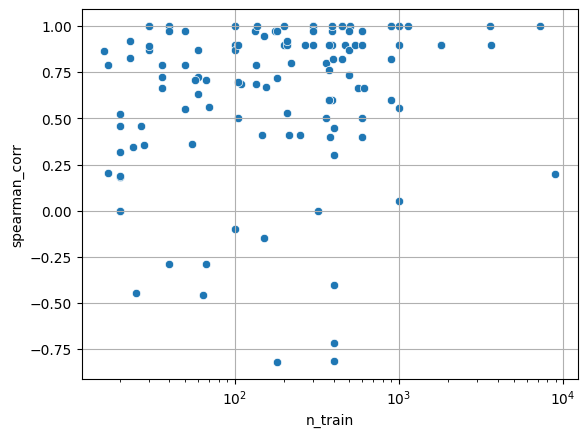

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=l.to_pandas(), x="n_train", y="spearman_corr")
plt.xscale("log")
plt.grid()

In [25]:
l.sort("n_train")

dataset,spearman_corr,n_train,n_test,n_classes,series_length
str,f64,i64,i64,i64,i64
"""DiatomSizeReduction""",0.866025,16,306,4,1
"""DodgerLoopGame""",0.205196,17,127,2,1
"""InsectEPGSmallTrain""",0.790569,17,249,3,1
"""DodgerLoopWeekend""",NaN,18,126,2,1
"""Fungi""",NaN,18,186,18,1
…,…,…,…,…,…
"""PhalangesOutlinesCorrect""",0.9,1800,858,2,1
"""FordA""",1.0,3601,1320,2,1
"""FordB""",0.9,3636,810,2,1
